In [1]:
import numpy as np
fruits = np.load("fruits_300.npy")
fruits_2d = fruits.reshape(-1,10000)

In [2]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)
pca.fit(fruits_2d)

PCA(n_components=50)

In [3]:
import matplotlib.pyplot as plt

def draw_fruits(arr,ratio = 1):
    n = len(arr)
    rows = int(np.ceil(n/10))
    cols = n if rows < 2 else 10
    fig, axs = plt.subplots(rows,cols,figsize =(cols*ratio,rows*ratio),squeeze = False)
    
    for i in range(rows):
        for j in range(cols):
            if i*10 + j < n:
                axs[i,j].imshow(arr[i*10]+j,cmap="gray_r")
            axs[i,j].axis("off")
    plt.show()

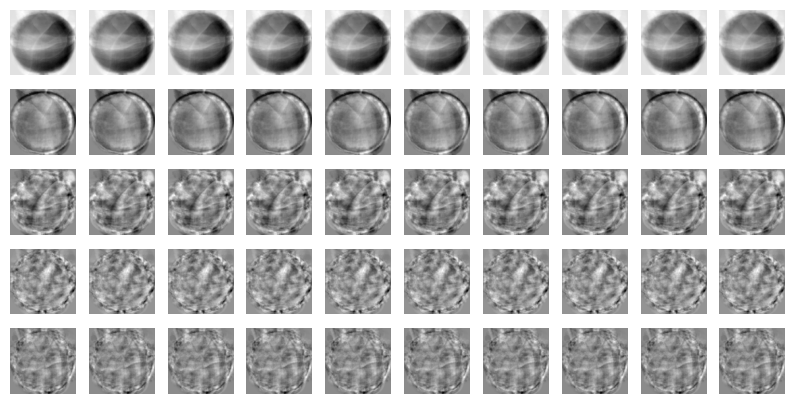

In [4]:
draw_fruits(pca.components_.reshape(-1,100,100))

In [6]:
fruits_pca = pca.transform(fruits_2d)
print(fruits_pca.shape)

(300, 50)


In [7]:
fruits_inverse = pca.inverse_transform(fruits_pca)
print(fruits_inverse.shape)

(300, 10000)


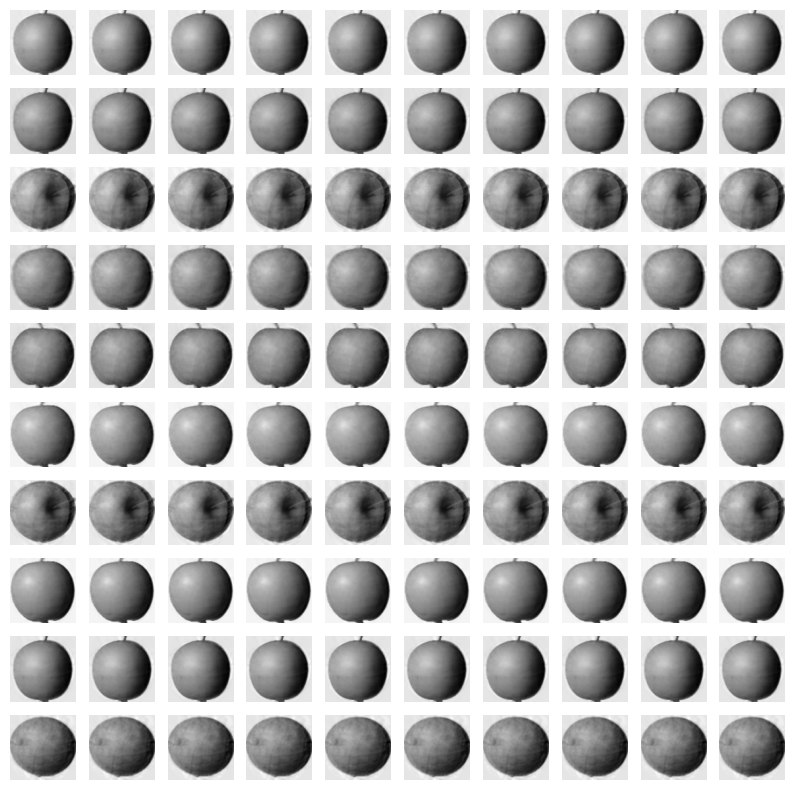

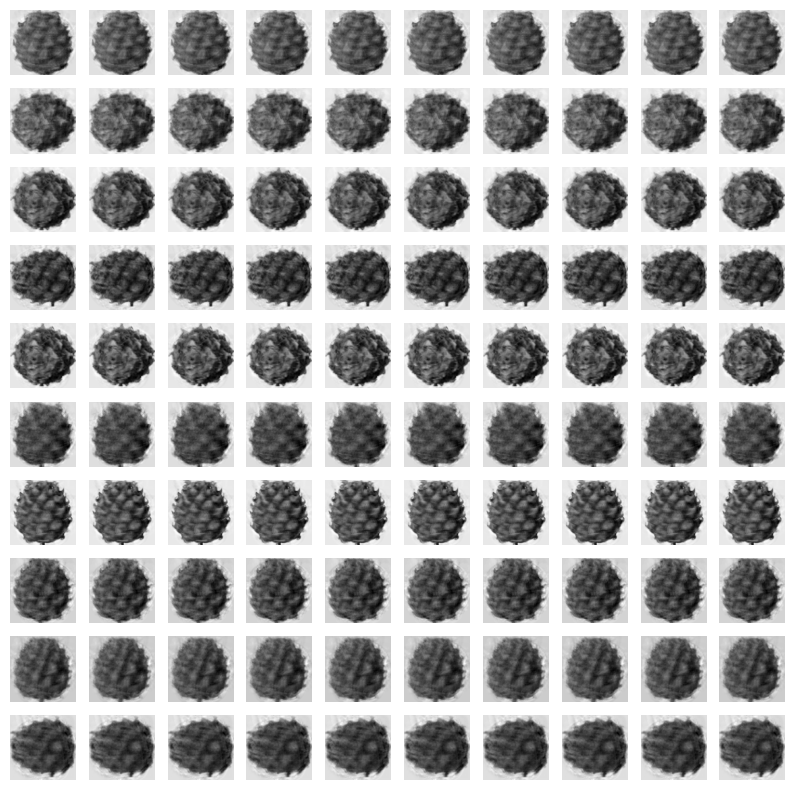

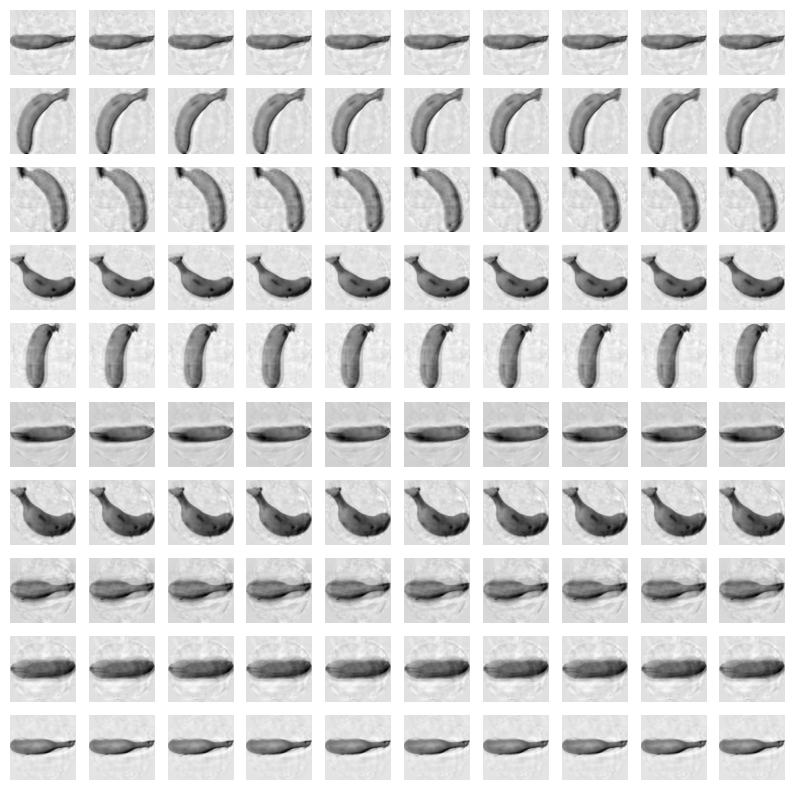

In [8]:
fruits_reconstruct = fruits_inverse.reshape(-1,100,100)
for start in [0,100,200]:
    draw_fruits(fruits_reconstruct[start:start+100])
    print("\n")

In [9]:
print(np.sum(pca.explained_variance_ratio_))

0.9215203768463156


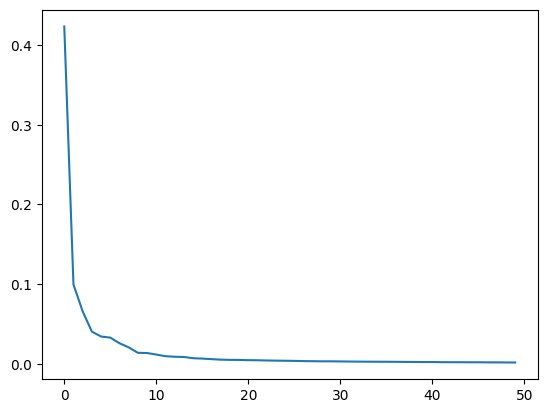

In [10]:
plt.plot(pca.explained_variance_ratio_)
plt.show()

In [11]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
target = np.array([0]*100+[1]*100+[2]*100)


In [13]:
from sklearn.model_selection import cross_validate

scores = cross_validate(lr,fruits_2d,target)
print(np.mean(scores["test_score"]))
print(np.mean(scores["fit_time"]))

0.9966666666666667
0.49994239807128904


In [ ]:
scores = cross_validate(lr,fruits_pca,target)
print(np.mean(scores["test_score"]))
print(np.mean(scores["fit_time"]))

#성능 동일 + 시간 1/30

0.9966666666666667
0.015549182891845703


In [15]:
pca = PCA(n_components=0.5)
pca.fit(fruits_2d)
print(pca.n_components_)

2


In [16]:
fruits_pca = pca.transform(fruits_2d)
scores = cross_validate(lr,fruits_pca,target)
print(np.mean(scores["test_score"]))
print(np.mean(scores["fit_time"]))

0.99
0.031539535522460936


c:\Users\조영석\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\조영석\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable

In [17]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3,random_state=42)
km.fit(fruits_pca)
print(np.unique(km.labels_,return_counts = True))

(array([0, 1, 2]), array([110,  99,  91], dtype=int64))


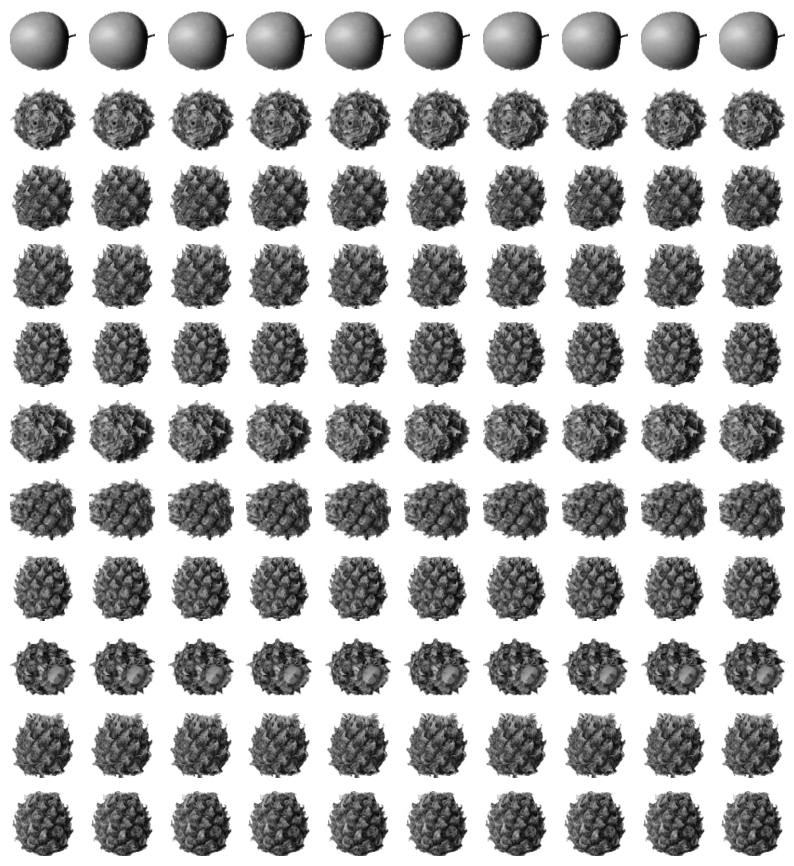

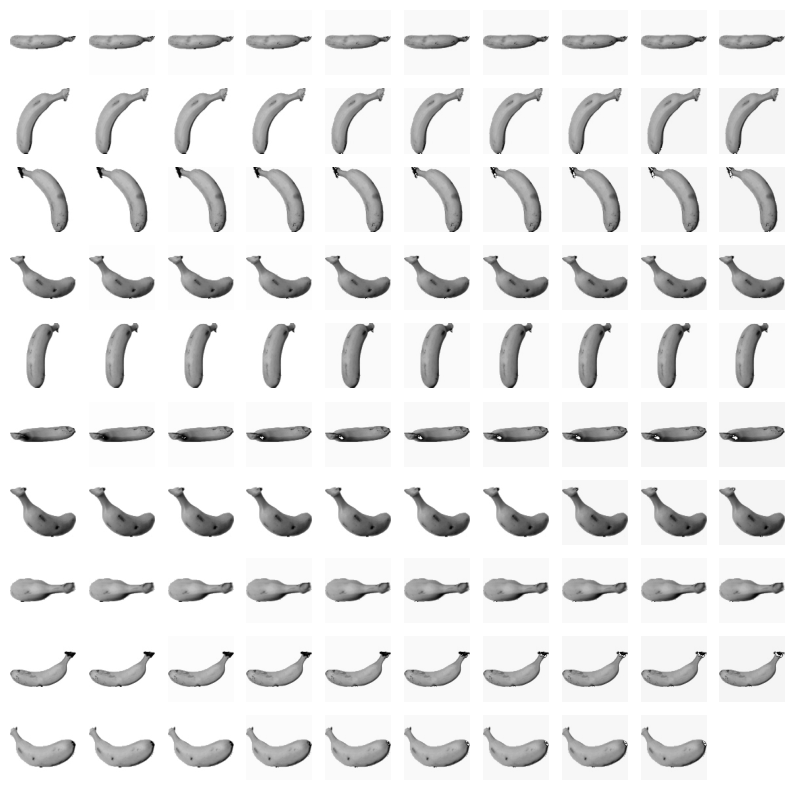

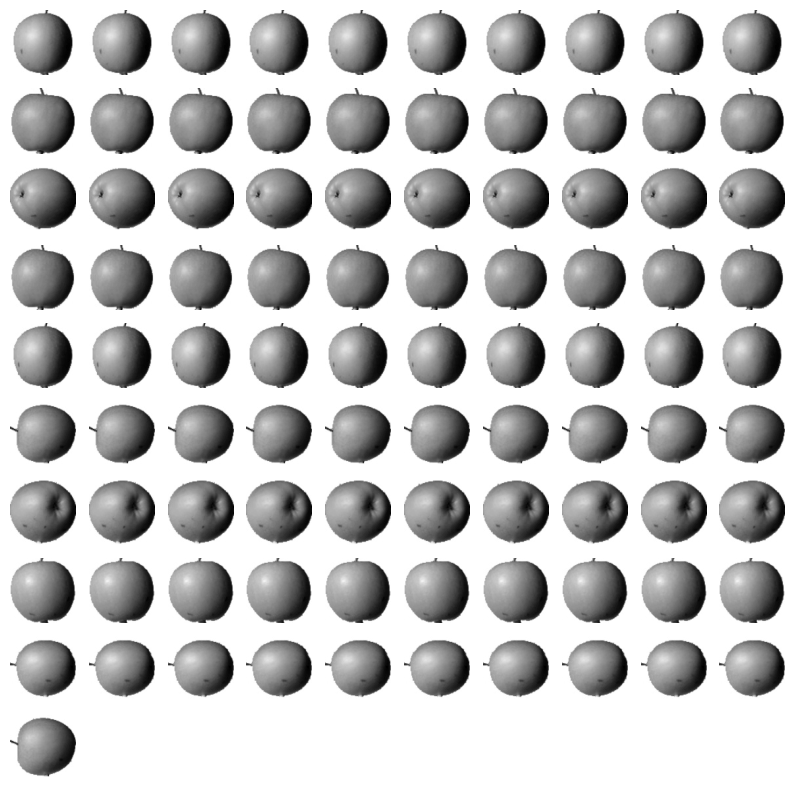

In [19]:
for label in range(0,3):
    draw_fruits(fruits[km.labels_ == label])
    print("\n")

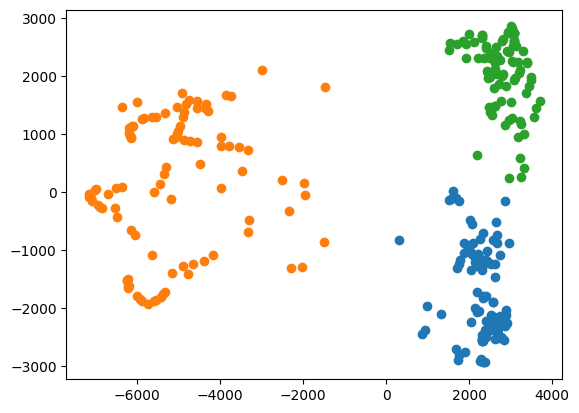

In [21]:
for label in range(0,3):
    data = fruits_pca[km.labels_ == label]
    plt.scatter(data[:,0],data[:,1])
    
plt.show()